# Stage 2 Alpha/Beta Explorer

This notebook mirrors the Stage 1 alpha/beta walkthrough but points at Stage 2 artifacts. Use it to inspect how thresholds behave on the Stage 2 datasets and recreate the charts stored in `data/charts`.


## Notebook goals
- Load processed candles and Stage 2 reports
- Derive alpha/beta the paper way and visualize the underlying return distributions
- Explore how label volumes shift as you tweak alpha/beta percentiles or scalars
- Plot baseline label mixes across `(backW, forW)` and highlight example windows on candlestick charts
- Save charts under `data/charts_stage2` so they stay separate from Stage 1 outputs


In [20]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

try:
    import yaml  # type: ignore
except ImportError:  # pragma: no cover - optional dependency
    yaml = None

from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 140,
})
pd.options.display.float_format = lambda v: f"{v:0.6f}"

In [21]:
LABEL_VALUES = ["BUY", "HOLD", "SELL"]


def safe_interval_name(interval: str) -> str:
    return interval.replace("/", "-")


def interval_to_minutes(interval: str) -> int:
    units = {"m": 1, "h": 60, "d": 1440, "w": 10080}
    if not interval:
        raise ValueError("Interval string is empty")
    value_part, unit = interval[:-1], interval[-1].lower()
    if unit not in units:
        raise ValueError(f"Unsupported interval unit: {interval}")
    try:
        value = int(value_part)
    except ValueError as exc:
        raise ValueError(f"Invalid interval value: {interval}") from exc
    return value * units[unit]


def ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.index, pd.DatetimeIndex):
        return df.sort_index()
    idx_col = "open_time" if "open_time" in df.columns else df.columns[0]
    df = df.copy()
    df[idx_col] = pd.to_datetime(df[idx_col], utc=True)
    df = df.set_index(idx_col)
    return df.sort_index()


def compute_forward_returns(df: pd.DataFrame, forW: int, fee: float) -> pd.Series:
    if forW < 1:
        raise ValueError("forW must be >= 1")
    future_close = df["close"].shift(-forW)
    forward = ((1.0 - fee) * future_close - (1.0 + fee) * df["open"]) / df["open"]
    forward.name = f"forward_{forW}"
    return forward


def build_window_index(df: pd.DataFrame, backW: int, forW: int) -> pd.DataFrame:
    if backW < 1 or forW < 1:
        raise ValueError("backW and forW must be >= 1")
    n = len(df)
    start = backW - 1
    end = n - forW
    if end <= start:
        empty = pd.DatetimeIndex([])
        return pd.DataFrame(columns=["t", "backW", "forW"], index=empty)
    idx = df.index[start:end]
    return pd.DataFrame({"t": idx, "backW": backW, "forW": forW}, index=idx)


def assign_labels(forward: pd.Series, alpha: float, beta: float) -> pd.Series:
    labels = pd.Series("HOLD", index=forward.index, dtype="object")
    valid = forward.notna()
    labels.loc[~valid] = pd.NA
    if valid.any():
        slice_forward = forward[valid]
        buy_mask = (slice_forward > alpha) & (slice_forward < beta)
        sell_mask = (slice_forward < -alpha) & (slice_forward > -beta)
        labels.loc[buy_mask.index[buy_mask]] = "BUY"
        labels.loc[sell_mask.index[sell_mask]] = "SELL"
    cat_dtype = pd.CategoricalDtype(categories=LABEL_VALUES)
    return labels.astype(cat_dtype)

In [22]:
def _infer_candle_width(index: pd.DatetimeIndex, minutes_per_candle: int) -> float:
    if len(index) >= 2:
        date_nums = mdates.date2num(index.to_pydatetime())
        diffs = np.diff(date_nums)
        diffs = diffs[diffs > 0]
        if diffs.size:
            return float(np.median(diffs) * 0.8)
    base = max(minutes_per_candle, 1) / (24.0 * 60.0)
    return float(max(base * 0.8, 1e-4))


def _plot_candles(ax: plt.Axes,
                  context: pd.DataFrame,
                  candle_width: float,
                  *,
                  time_only: bool = False) -> Dict[pd.Timestamp, float]:
    date_nums = mdates.date2num(context.index.to_pydatetime())
    idx_to_num = dict(zip(context.index, date_nums))
    half_width = candle_width / 2.0
    up_color = "#2ca02c"
    down_color = "#d62728"
    for x, row in zip(date_nums, context.itertuples()):
        open_, high, low, close = row.open, row.high, row.low, row.close
        color = up_color if close >= open_ else down_color
        ax.vlines(x, low, high, color=color, linewidth=1.0, zorder=2)
        body_bottom = min(open_, close)
        body_height = abs(close - open_)
        if body_height < 1e-12:
            ax.hlines(open_, x - half_width, x + half_width, color=color, linewidth=1.2, zorder=3)
        else:
            rect = Rectangle((x - half_width, body_bottom), candle_width, body_height,
                             facecolor=color, edgecolor=color, alpha=0.7, linewidth=0.8, zorder=3)
            ax.add_patch(rect)
    ax.set_xlim(date_nums[0] - half_width * 1.4, date_nums[-1] + half_width * 1.4)
    ax.xaxis_date()
    fmt = "%H:%M" if time_only else "%Y-%m-%d %H:%M"
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))
    return idx_to_num


def move_legend(ax: plt.Axes,
                *,
                location: str = "upper left",
                anchor: Tuple[float, float] = (1.02, 1.0),
                ncol: int = 1,
                frameon: bool = False) -> None:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, loc=location, bbox_to_anchor=anchor, ncol=ncol, frameon=frameon)


def finalize_figure(fig: plt.Figure,
                    filename: str,
                    *,
                    charts_dir: Path | None = None,
                    tight: bool = True,
                    dpi: int = 220,
                    close: bool = False) -> None:
    global CHARTS_DIR
    target_dir = charts_dir or CHARTS_DIR
    target_dir.mkdir(parents=True, exist_ok=True)
    if tight:
        fig.tight_layout()
    fig.savefig(target_dir / filename, dpi=dpi, bbox_inches="tight")
    if close:
        plt.close(fig)


def plot_window_example(ax: plt.Axes,
                        df: pd.DataFrame,
                        ts: pd.Timestamp,
                        backW: int,
                        forW: int,
                        forward_value: float,
                        alpha_val: float,
                        beta_val: float,
                        minutes_per_candle: int,
                        pad_candles: int | None = None) -> None:
    pos = df.index.get_loc(ts)
    window_start = pos - backW + 1
    window_end = pos + forW + 1
    if pad_candles is None:
        pad = max(3, backW // 2, forW // 2)
    else:
        pad = max(int(pad_candles), 0)
    ctx_start = max(0, window_start - pad)
    ctx_end = min(len(df), window_end + pad)
    context = df.iloc[ctx_start:ctx_end][["open", "high", "low", "close"]]
    window_df = df.iloc[window_start:window_end][["open", "high", "low", "close"]]
    candle_width = _infer_candle_width(context.index, minutes_per_candle)
    idx_to_num = _plot_candles(ax, context, candle_width, time_only=True)
    half = candle_width / 2.0

    back_slice = window_df.iloc[:backW]
    forward_slice = window_df.iloc[-forW:] if forW > 0 else window_df.iloc[0:0]
    back_left = idx_to_num[back_slice.index[0]] - half
    back_right = idx_to_num[back_slice.index[-1]] + half
    ax.axvspan(back_left, back_right, color="#1f77b4", alpha=0.18, label=f"backW={backW}", zorder=1)
    if not forward_slice.empty:
        forward_left = idx_to_num[ts]
        forward_right = idx_to_num[forward_slice.index[-1]] + half
        ax.axvspan(forward_left, forward_right, color="#ff7f0e", alpha=0.16, label=f"forW={forW}", zorder=1)

    entry_price = df.loc[ts, "open"]
    entry_num = idx_to_num[ts]
    exit_ts = df.index[pos + forW]
    exit_price = df.loc[exit_ts, "close"]
    exit_num = idx_to_num[exit_ts]
    ax.scatter([entry_num], [entry_price], color="#1f77b4", marker="^", s=70,
               zorder=6, label="entry (open_t)")
    ax.scatter([exit_num], [exit_price], color="#d62728", marker="v", s=70,
               zorder=6, label=f"exit (close_t+{forW})")
    ax.plot([entry_num, exit_num], [entry_price, exit_price], color="#7f7f7f",
            linestyle="--", linewidth=1.1, zorder=4, label="trade path")

    note = (
        f"forward={forward_value:.4f}\n"
        f"alpha={alpha_val:.4f} beta={beta_val:.4f}\n"
        f"entry={entry_price:.4f} exit={exit_price:.4f}"
    )
    ax.text(0.02, 0.95, note, transform=ax.transAxes, ha="left", va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85), fontsize=10)
    move_legend(ax, anchor=(1.01, 1.0))
    ax.set_title(f"Window around {ts:%Y-%m-%d %H:%M} (backW={backW}, forW={forW})")
    ax.set_ylabel("Price (quote)")
    ax.grid(True, alpha=0.18)


def plot_recent_candles(ax: plt.Axes,
                        df: pd.DataFrame,
                        lookback: int,
                        minutes_per_candle: int,
                        title: str) -> None:
    context = df.tail(lookback)
    candle_width = _infer_candle_width(context.index, minutes_per_candle)
    _plot_candles(ax, context, candle_width, time_only=False)
    ax.set_title(title)
    ax.set_ylabel("Price (quote)")
    ax.grid(True, alpha=0.2)


In [23]:
def summarize_threshold_scenario(scenario: str,
                               alpha_val: float,
                               beta_base: float,
                               price_df: pd.DataFrame,
                               forward_lookup: Dict[int, pd.Series],
                               backW_values: Iterable[int],
                               forW_values: Iterable[int],
                               scale_beta_per_step: float) -> pd.DataFrame:
    records: List[Dict[str, object]] = []
    for backW in backW_values:
        for forW in forW_values:
            beta = beta_base * (1.0 + scale_beta_per_step * (forW - 1))
            beta = max(beta, alpha_val)
            windows = build_window_index(price_df, backW, forW)
            idx = windows.index
            forward_series = forward_lookup[forW].reindex(idx)
            labels = assign_labels(forward_series, alpha_val, beta)
            counts = labels.value_counts(dropna=False).reindex(LABEL_VALUES, fill_value=0)
            n_total = len(labels)
            valid_mask = labels.notna()
            n_valid = int(valid_mask.sum())
            buy = int(counts.get("BUY", 0))
            hold = int(counts.get("HOLD", 0))
            sell = int(counts.get("SELL", 0))
            record = {
                "scenario": scenario,
                "backW": int(backW),
                "forW": int(forW),
                "alpha": float(alpha_val),
                "beta": float(beta),
                "beta_base": float(beta_base),
                "n_total": int(n_total),
                "n_valid": int(n_valid),
                "count_buy": buy,
                "count_hold": hold,
                "count_sell": sell,
                "share_buy": buy / n_valid if n_valid else 0.0,
                "share_hold": hold / n_valid if n_valid else 0.0,
                "share_sell": sell / n_valid if n_valid else 0.0,
            }
            records.append(record)
    return pd.DataFrame(records)


def aggregate_label_mix(df: pd.DataFrame) -> pd.DataFrame:
    totals = df.groupby("scenario").agg({
        "n_valid": "sum",
        "count_buy": "sum",
        "count_hold": "sum",
        "count_sell": "sum",
    }).reset_index()
    totals["share_buy"] = totals["count_buy"] / totals["n_valid"].where(totals["n_valid"] > 0, np.nan)
    totals["share_hold"] = totals["count_hold"] / totals["n_valid"].where(totals["n_valid"] > 0, np.nan)
    totals["share_sell"] = totals["count_sell"] / totals["n_valid"].where(totals["n_valid"] > 0, np.nan)
    return totals


def choose_window_examples(price_df: pd.DataFrame,
                           forward_lookup: Dict[int, pd.Series],
                           combos: List[Tuple[int, int]],
                           alpha_val: float,
                           beta_base: float,
                           scale_beta_per_step: float,
                           quantile: float = 0.65) -> List[Dict[str, object]]:
    examples: List[Dict[str, object]] = []
    for backW, forW in combos:
        beta = beta_base * (1.0 + scale_beta_per_step * (forW - 1))
        beta = max(beta, alpha_val)
        windows = build_window_index(price_df, backW, forW)
        forward_series = forward_lookup[forW].dropna()
        candidates = windows.index.intersection(forward_series.index)
        if len(candidates) == 0:
            continue
        idx = int(min(max(len(candidates) - 1, 0), round(len(candidates) * quantile)))
        ts = candidates[idx]
        forward_value = float(forward_series.loc[ts])
        examples.append({
            "backW": backW,
            "forW": forW,
            "ts": ts,
            "forward": forward_value,
            "beta": beta,
        })
    return examples

In [24]:
# --- Parameters (tweak as needed) ---
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "configs").exists() else NOTEBOOK_DIR.parent

LABEL_CFG_PATH = PROJECT_ROOT / "configs" / "labeling_stage2.yaml"
PATH_CFG_PATH = PROJECT_ROOT / "configs" / "paths_stage2.yaml"

paths_cfg = {}
if PATH_CFG_PATH.exists() and yaml is not None:
    with PATH_CFG_PATH.open("r", encoding="utf-8") as handle:
        paths_cfg = yaml.safe_load(handle) or {}

PROCESSED_DIR = (PROJECT_ROOT / paths_cfg.get("processed_dir", "stage1/stage2_data/processed")).expanduser().resolve()
REPORTS_DIR = (PROJECT_ROOT / paths_cfg.get("reports_dir", "stage1/stage2_data/reports")).expanduser().resolve()
DATASETS_DIR = (PROJECT_ROOT / paths_cfg.get("datasets_dir", "stage1/stage2_data/datasets")).expanduser().resolve()
CHARTS_DIR = PROJECT_ROOT / "data" / "charts_stage2"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

label_values: Dict[str, object] = {}
if LABEL_CFG_PATH.exists() and yaml is not None:
    with LABEL_CFG_PATH.open("r", encoding="utf-8") as handle:
        label_values = yaml.safe_load(handle) or {}

DEFAULT_INTERVAL = str(label_values.get("interval", "4h"))
DEFAULT_FEE = float(label_values.get("fee", 0.001))
backW_values = list(map(int, label_values.get("backW", [1, 2, 3, 4, 5])))
forW_values = list(map(int, label_values.get("forW", [1, 2, 3, 4, 5])))
scale_beta_per_step = float(label_values.get("scale_beta_per_step", 0.10))
percentiles_cfg = label_values.get("single_candle_percentiles", {}) or {}
ALPHA_PCT_CFG = float(percentiles_cfg.get("alpha_pct", 0.24))
BETA_PCT_CFG = float(percentiles_cfg.get("beta_pct", 0.997))

ALPHA_PERCENTILES_STUDY = [0.01, 0.05, 0.10, 0.24, 0.35]
BETA_PERCENTILES_STUDY = [0.990, 0.995, 0.997, 0.999]
ALPHA_SCALE_STUDY = [0.6, 0.8, 1.0, 1.2, 1.4]
WINDOW_SAMPLE_QUANTILE = 0.65
RECENT_CANDLES = 220
WINDOW_CONTEXT_PAD = 8


def _pick_default_symbol() -> str:
    best_symbol = None
    best_count = -1
    for path in REPORTS_DIR.glob("*_backW*_forW*.json"):
        try:
            payload = json.loads(path.read_text())
            n_valid = int(payload.get("n_valid", 0))
            symbol = payload.get("symbol")
            if symbol and n_valid > best_count:
                best_symbol = symbol
                best_count = n_valid
        except Exception:
            continue
    if best_symbol:
        return best_symbol
    raw_symbol = label_values.get("symbol", "BTCUSDT")
    if isinstance(raw_symbol, str) and "*" in raw_symbol:
        return raw_symbol.replace("*", "BTC")
    return str(raw_symbol)

SYMBOL = _pick_default_symbol()
INTERVAL = DEFAULT_INTERVAL
FEE = DEFAULT_FEE

print(f"Project root      : {PROJECT_ROOT}")
print(f"Label config      : {LABEL_CFG_PATH}")
print(f"Paths config      : {PATH_CFG_PATH}")
print(f"Symbol / interval : {SYMBOL} / {INTERVAL}")
print(f"Fee (round-trip)  : {FEE}")
print(f"backW candidates  : {backW_values}")
print(f"forW candidates   : {forW_values}")
print(f"alpha_pct (cfg)   : {ALPHA_PCT_CFG}")
print(f"beta_pct  (cfg)   : {BETA_PCT_CFG}")
print(f"Charts directory  : {CHARTS_DIR}")


Project root      : /home/kamil/binance-bot
Label config      : /home/kamil/binance-bot/configs/labeling_stage2.yaml
Paths config      : /home/kamil/binance-bot/configs/paths_stage2.yaml
Symbol / interval : KAVAUSDT / 4h
Fee (round-trip)  : 0.001
backW candidates  : [1, 2, 3, 4, 5]
forW candidates   : [1, 2, 3, 4, 5]
alpha_pct (cfg)   : 0.85
beta_pct  (cfg)   : 0.997
Charts directory  : /home/kamil/binance-bot/data/charts_stage2


In [25]:
safe_name = safe_interval_name(INTERVAL)
processed_path = PROCESSED_DIR / f"{SYMBOL}_{safe_name}.parquet"
if not processed_path.exists():
    raise FileNotFoundError(f"Missing processed parquet: {processed_path}")

price_df = pd.read_parquet(processed_path)
price_df = ensure_datetime_index(price_df)
price_df = price_df.loc[~price_df.index.duplicated(keep="first")]
price_df = price_df.sort_index()
required_cols = {"open", "high", "low", "close"}
missing_cols = required_cols - set(price_df.columns)
if missing_cols:
    raise KeyError(f"Processed dataframe is missing columns: {sorted(missing_cols)}")

interval_minutes = interval_to_minutes(INTERVAL)
print(f"Loaded {len(price_df):,} candles spanning {price_df.index.min()} to {price_df.index.max()}")
price_head = price_df[["open", "high", "low", "close"]].head()
display(price_head)

Loaded 13,072 candles spanning 2020-01-01 00:00:00+00:00 to 2025-12-18 16:00:00+00:00


,open,high,low,close
ts,,,,
2020-01-01 00:00:00+00:00,1.118500,1.139500,1.116700,1.133000
2020-01-01 04:00:00+00:00,1.129500,1.134800,1.093300,1.096200
2020-01-01 08:00:00+00:00,1.100000,1.104300,1.074500,1.093200
2020-01-01 12:00:00+00:00,1.097300,1.135400,1.093500,1.106000
2020-01-01 16:00:00+00:00,1.105900,1.128500,1.085000,1.115400


In [26]:
pattern = f"{SYMBOL}_{safe_interval_name(INTERVAL)}_backW*_forW*.json"
report_payloads: List[Dict[str, object]] = []
for path in sorted(REPORTS_DIR.glob(pattern)):
    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    report_payloads.append(payload)

if report_payloads:
    reports_df = pd.DataFrame(report_payloads)
    reports_df = reports_df.sort_values(["backW", "forW"]).reset_index(drop=True)
    display(reports_df.head())
else:
    reports_df = pd.DataFrame()
    print("No Stage 1 report JSON files were found; continuing with config defaults only.")

,symbol,interval,backW,forW,alpha,beta,fee,dataset_path,counts,distribution,n_valid,n_total
0,KAVAUSDT,4h,1,1,0.041944,0.203349,0.001000,/home/kamil/binance-bot/stage1/stage2_data/dat...,"{'BUY': 967, 'HOLD': 11007, 'SELL': 1097, 'NaN...","{'BUY': 0.07398056766888532, 'HOLD': 0.8420931...",13071,13071
1,KAVAUSDT,4h,1,2,0.041944,0.223684,0.001000,/home/kamil/binance-bot/stage1/stage2_data/dat...,"{'BUY': 1313, 'HOLD': 10276, 'SELL': 1481, 'Na...","{'BUY': 0.10045906656465188, 'HOLD': 0.7862280...",13070,13070
2,KAVAUSDT,4h,1,3,0.041944,0.244019,0.001000,/home/kamil/binance-bot/stage1/stage2_data/dat...,"{'BUY': 1623, 'HOLD': 9637, 'SELL': 1809, 'NaN...","{'BUY': 0.124187007422144, 'HOLD': 0.737393832...",13069,13069
3,KAVAUSDT,4h,1,4,0.041944,0.264354,0.001000,/home/kamil/binance-bot/stage1/stage2_data/dat...,"{'BUY': 1919, 'HOLD': 9033, 'SELL': 2116, 'NaN...","{'BUY': 0.14684726048362412, 'HOLD': 0.6912304...",13068,13068
4,KAVAUSDT,4h,1,5,0.041944,0.284689,0.001000,/home/kamil/binance-bot/stage1/stage2_data/dat...,"{'BUY': 2175, 'HOLD': 8531, 'SELL': 2361, 'NaN...","{'BUY': 0.16644983546338105, 'HOLD': 0.6528659...",13067,13067


In [27]:
forward_returns: Dict[int, pd.Series] = {}
forward_stats: List[Dict[str, float]] = []
for forW in forW_values:
    series = compute_forward_returns(price_df, forW, FEE)
    forward_returns[forW] = series
    valid = series.dropna()
    if not valid.empty:
        forward_stats.append({
            "forW": forW,
            "mean": valid.mean(),
            "std": valid.std(),
            "median": valid.median(),
            "p10": valid.quantile(0.10),
            "p90": valid.quantile(0.90),
        })

single_forward = forward_returns[1]
single_abs = single_forward.abs().dropna()
alpha_base = float(single_abs.quantile(ALPHA_PCT_CFG))
beta_base = float(single_abs.quantile(BETA_PCT_CFG))
if beta_base < alpha_base:
    beta_base = alpha_base

threshold_rows = []
for forW in forW_values:
    beta = beta_base * (1.0 + scale_beta_per_step * (forW - 1))
    threshold_rows.append({"forW": forW, "alpha": alpha_base, "beta": beta})
threshold_df = pd.DataFrame(threshold_rows)
forward_stats_df = pd.DataFrame(forward_stats)

print("Baseline thresholds (exact_paper style):")
display(threshold_df)
if not forward_stats_df.empty:
    display(forward_stats_df)

Baseline thresholds (exact_paper style):


,forW,alpha,beta
0,1,0.043457,0.175830
1,2,0.043457,0.193413
2,3,0.043457,0.210996
3,4,0.043457,0.228579
4,5,0.043457,0.246162


,forW,mean,std,median,p10,p90
0,1,-0.001743,0.036304,-0.002000,-0.038259,0.034174
1,2,-0.001640,0.043825,-0.002000,-0.045768,0.042495
2,3,-0.001547,0.050026,-0.002000,-0.053260,0.050172
3,4,-0.001440,0.055774,-0.002000,-0.058849,0.056693
4,5,-0.001326,0.061051,-0.002000,-0.065005,0.063195


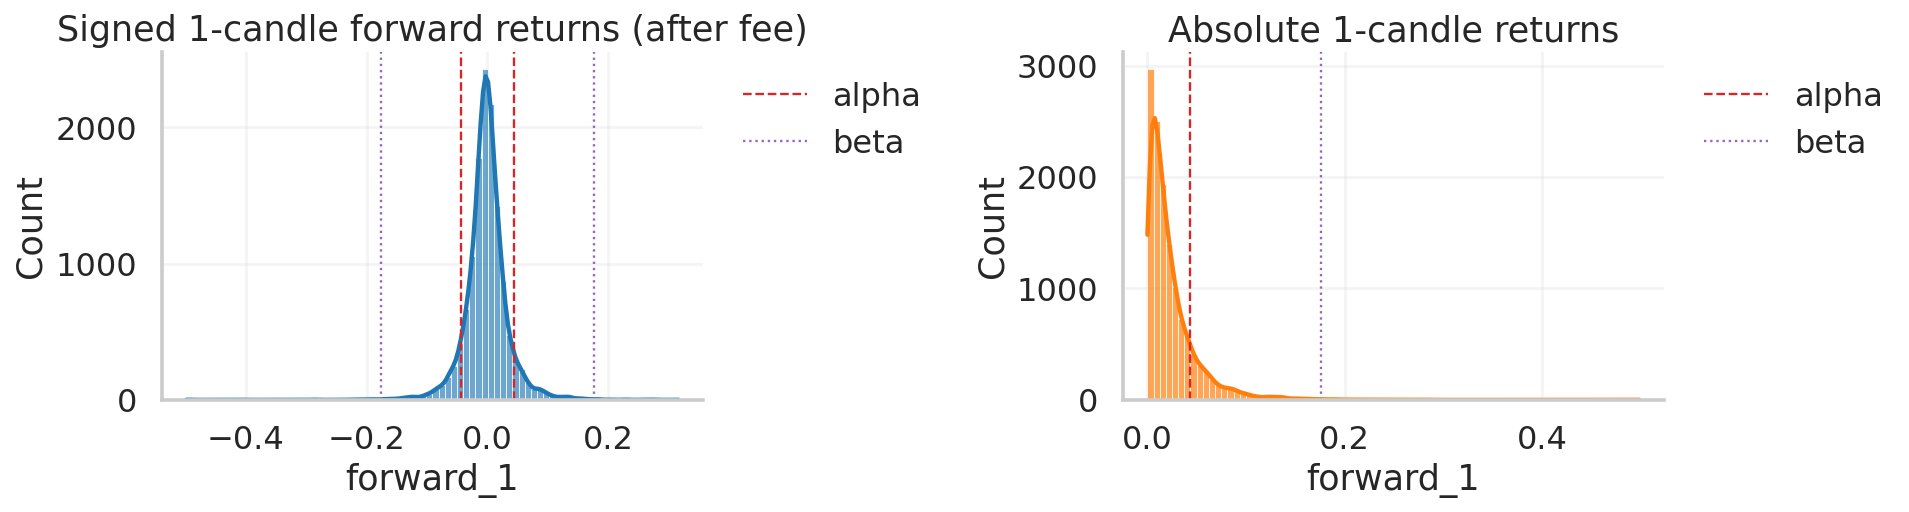

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax0, ax1 = axes
sns.histplot(single_forward.dropna(), bins=80, kde=True, ax=ax0, color="#1f77b4", alpha=0.65)
ax0.axvline(alpha_base, color="#d62728", linestyle="--", linewidth=1.2, label="alpha")
ax0.axvline(-alpha_base, color="#d62728", linestyle="--", linewidth=1.2)
ax0.axvline(beta_base, color="#9467bd", linestyle=":", linewidth=1.2, label="beta")
ax0.axvline(-beta_base, color="#9467bd", linestyle=":", linewidth=1.2)
ax0.set_title("Signed 1-candle forward returns (after fee)")
move_legend(ax0, anchor=(1.02, 1.0))
ax0.grid(True, alpha=0.2)

sns.histplot(single_abs, bins=80, kde=True, ax=ax1, color="#ff7f0e", alpha=0.7)
ax1.axvline(alpha_base, color="#d62728", linestyle="--", linewidth=1.2, label="alpha")
ax1.axvline(beta_base, color="#9467bd", linestyle=":", linewidth=1.2, label="beta")
ax1.set_title("Absolute 1-candle returns")
move_legend(ax1, anchor=(1.02, 1.0))
ax1.grid(True, alpha=0.2)
finalize_figure(fig, "forward_return_distributions.png")
plt.show()

Baseline label mix per scenario (aggregated over all backW/forW):


,scenario,n_valid,count_buy,count_hold,count_sell,share_buy,share_hold,share_sell
0,baseline,326675,37985,246805,41885,0.116278,0.755506,0.128216


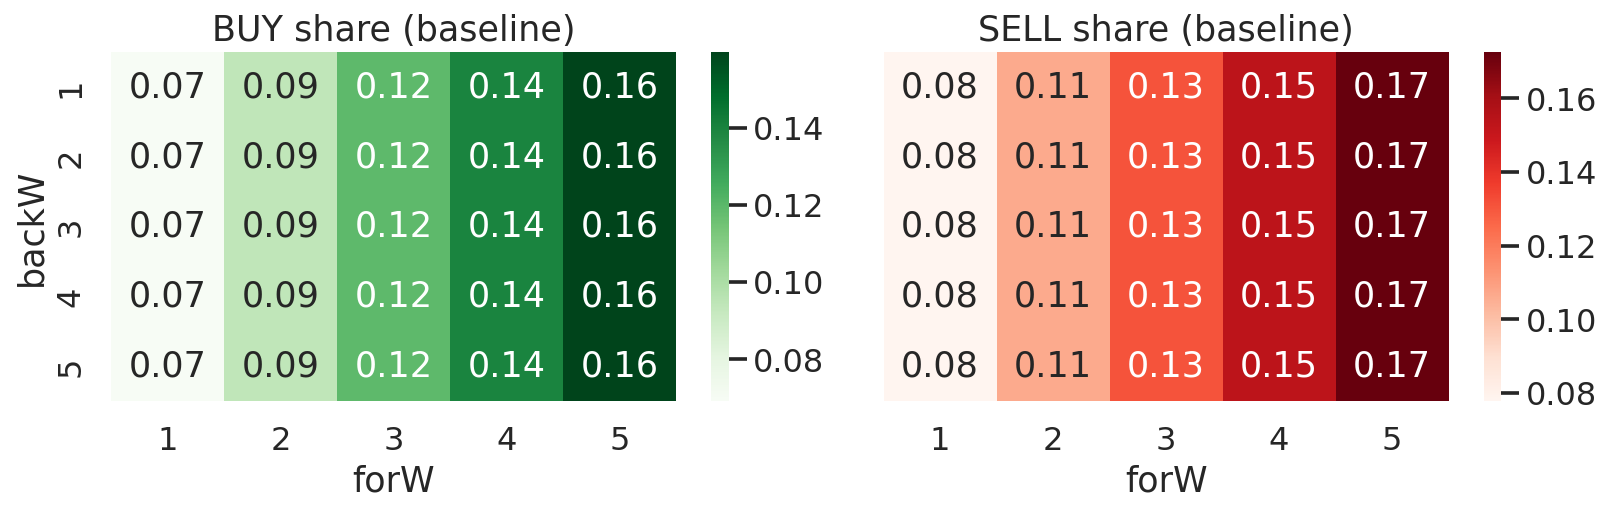

In [29]:
baseline_df = summarize_threshold_scenario(
    scenario="baseline",
    alpha_val=alpha_base,
    beta_base=beta_base,
    price_df=price_df,
    forward_lookup=forward_returns,
    backW_values=backW_values,
    forW_values=forW_values,
    scale_beta_per_step=scale_beta_per_step,
)

baseline_totals = aggregate_label_mix(baseline_df)
print("Baseline label mix per scenario (aggregated over all backW/forW):")
display(baseline_totals)

pivot_buy = baseline_df.pivot(index="backW", columns="forW", values="share_buy")
pivot_sell = baseline_df.pivot(index="backW", columns="forW", values="share_sell")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
sns.heatmap(pivot_buy, ax=axes[0], cmap="Greens", annot=True, fmt=".2f")
axes[0].set_title("BUY share (baseline)")
axes[0].set_xlabel("forW")
axes[0].set_ylabel("backW")
sns.heatmap(pivot_sell, ax=axes[1], cmap="Reds", annot=True, fmt=".2f")
axes[1].set_title("SELL share (baseline)")
axes[1].set_xlabel("forW")
axes[1].set_ylabel("")
finalize_figure(fig, "baseline_label_heatmaps.png")
plt.show()

Alpha percentile sensitivity (aggregated label mix):


,scenario,n_valid,count_buy,count_hold,count_sell,share_buy,share_hold,share_sell
0,alpha_pct=0.010,326675,152187,4324,170164,0.465867,0.013236,0.520897
1,alpha_pct=0.050,326675,147392,13984,165299,0.451188,0.042807,0.506004
2,alpha_pct=0.100,326675,141377,26281,159017,0.432776,0.080450,0.486774
3,alpha_pct=0.240,326675,124860,60674,141141,0.382215,0.185732,0.432053
4,alpha_pct=0.350,326675,111615,88769,126291,0.341670,0.271735,0.386595
5,alpha_pct=0.850,326675,37985,246805,41885,0.116278,0.755506,0.128216


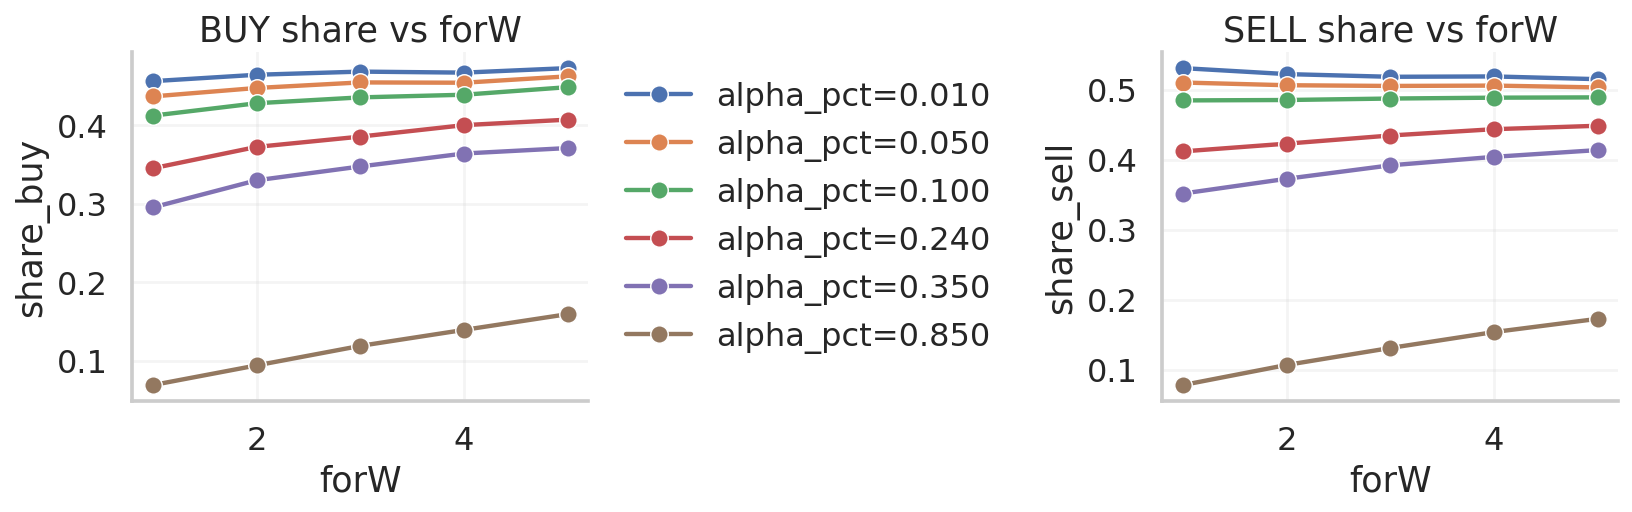

In [30]:
alpha_pct_grid = sorted(set(ALPHA_PERCENTILES_STUDY + [ALPHA_PCT_CFG]))
alpha_summaries: List[pd.DataFrame] = []
for pct in alpha_pct_grid:
    alpha_candidate = float(single_abs.quantile(pct))
    if np.isnan(alpha_candidate):
        continue
    scenario_name = f"alpha_pct={pct:.3f}"
    df_summary = summarize_threshold_scenario(
        scenario=scenario_name,
        alpha_val=alpha_candidate,
        beta_base=beta_base,
        price_df=price_df,
        forward_lookup=forward_returns,
        backW_values=backW_values,
        forW_values=forW_values,
        scale_beta_per_step=scale_beta_per_step,
    )
    df_summary["alpha_pct"] = pct
    alpha_summaries.append(df_summary)

if alpha_summaries:
    alpha_summary_df = pd.concat(alpha_summaries, ignore_index=True)
    alpha_totals = aggregate_label_mix(alpha_summary_df)
    print("Alpha percentile sensitivity (aggregated label mix):")
    display(alpha_totals)
    alpha_line = (
        alpha_summary_df.groupby(["scenario", "forW"])
        .agg({"share_buy": "mean", "share_sell": "mean"})
        .reset_index()
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    sns.lineplot(data=alpha_line, x="forW", y="share_buy", hue="scenario", marker="o", ax=axes[0])
    axes[0].set_title("BUY share vs forW")
    axes[0].grid(True, alpha=0.2)
    move_legend(axes[0], anchor=(1.02, 1.0))
    sns.lineplot(data=alpha_line, x="forW", y="share_sell", hue="scenario", marker="o", ax=axes[1])
    axes[1].set_title("SELL share vs forW")
    axes[1].grid(True, alpha=0.2)
    legend1 = axes[1].get_legend()
    if legend1 is not None:
        legend1.remove()
    finalize_figure(fig, "alpha_percentile_sensitivity.png")
    plt.show()
else:
    print("Alpha percentile sensitivity skipped (no valid summaries).")

Beta percentile sensitivity (aggregated label mix):


,scenario,n_valid,count_buy,count_hold,count_sell,share_buy,share_hold,share_sell
0,beta_pct=0.990,326675,36535,249575,40565,0.111839,0.763986,0.124175
1,beta_pct=0.995,326675,37525,247665,41485,0.114870,0.758139,0.126992
2,beta_pct=0.997,326675,37985,246805,41885,0.116278,0.755506,0.128216
3,beta_pct=0.999,326675,38470,245770,42435,0.117762,0.752338,0.129900


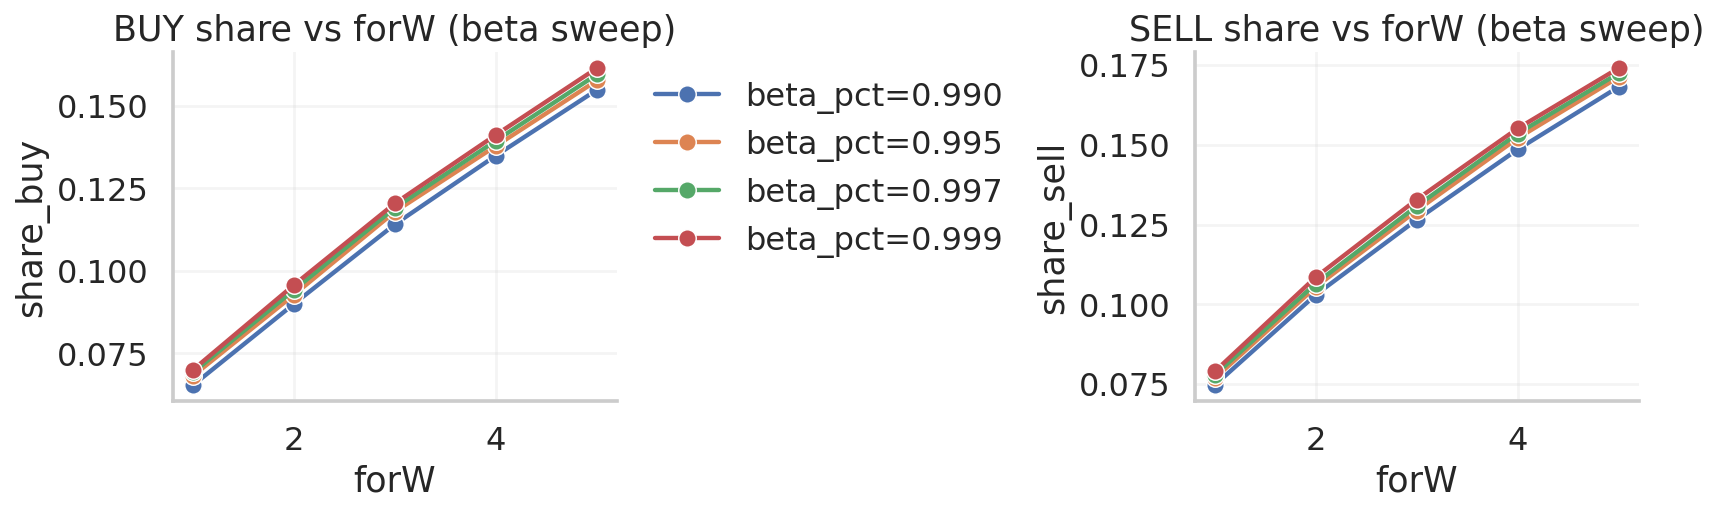

In [31]:
beta_pct_grid = sorted(set(BETA_PERCENTILES_STUDY + [BETA_PCT_CFG]))
beta_summaries: List[pd.DataFrame] = []
for pct in beta_pct_grid:
    beta_candidate = float(single_abs.quantile(pct))
    if np.isnan(beta_candidate):
        continue
    beta_candidate = max(beta_candidate, alpha_base)
    scenario_name = f"beta_pct={pct:.3f}"
    df_summary = summarize_threshold_scenario(
        scenario=scenario_name,
        alpha_val=alpha_base,
        beta_base=beta_candidate,
        price_df=price_df,
        forward_lookup=forward_returns,
        backW_values=backW_values,
        forW_values=forW_values,
        scale_beta_per_step=scale_beta_per_step,
    )
    df_summary["beta_pct"] = pct
    beta_summaries.append(df_summary)

if beta_summaries:
    beta_summary_df = pd.concat(beta_summaries, ignore_index=True)
    beta_totals = aggregate_label_mix(beta_summary_df)
    print("Beta percentile sensitivity (aggregated label mix):")
    display(beta_totals)
    beta_line = (
        beta_summary_df.groupby(["scenario", "forW"])
        .agg({"share_buy": "mean", "share_sell": "mean"})
        .reset_index()
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    sns.lineplot(data=beta_line, x="forW", y="share_buy", hue="scenario", marker="o", ax=axes[0])
    axes[0].set_title("BUY share vs forW (beta sweep)")
    axes[0].grid(True, alpha=0.2)
    move_legend(axes[0], anchor=(1.02, 1.0))
    sns.lineplot(data=beta_line, x="forW", y="share_sell", hue="scenario", marker="o", ax=axes[1])
    axes[1].set_title("SELL share vs forW (beta sweep)")
    axes[1].grid(True, alpha=0.2)
    legend2 = axes[1].get_legend()
    if legend2 is not None:
        legend2.remove()
    finalize_figure(fig, "beta_percentile_sensitivity.png")
    plt.show()
else:
    print("Beta percentile sensitivity skipped (no summaries).")

In [32]:
ALPHA_PERCENTILES_STUDY = [0.01, 0.05, 0.10, 0.24, 0.35]
BETA_PERCENTILES_STUDY = [0.990, 0.995, 0.997, 0.999]
ALPHA_SCALE_STUDY = [0.6, 0.8, 1.0, 1.2, 1.4]
WINDOW_SAMPLE_QUANTILE = 0.65
RECENT_CANDLES = 220
WINDOW_CONTEXT_PAD = 8

Alpha scaling sensitivity (scaling alpha & beta together):


,scenario,n_valid,count_buy,count_hold,count_sell,share_buy,share_hold,share_sell
0,alpha_scale=0.60,326675,61257,194669,70749,0.187517,0.595910,0.216573
1,alpha_scale=0.80,326675,48625,223330,54720,0.148848,0.683646,0.167506
2,alpha_scale=1.00,326675,37985,246805,41885,0.116278,0.755506,0.128216
3,alpha_scale=1.20,326675,29850,264425,32400,0.091375,0.809444,0.099181
4,alpha_scale=1.40,326675,23395,278200,25080,0.071616,0.851611,0.076774


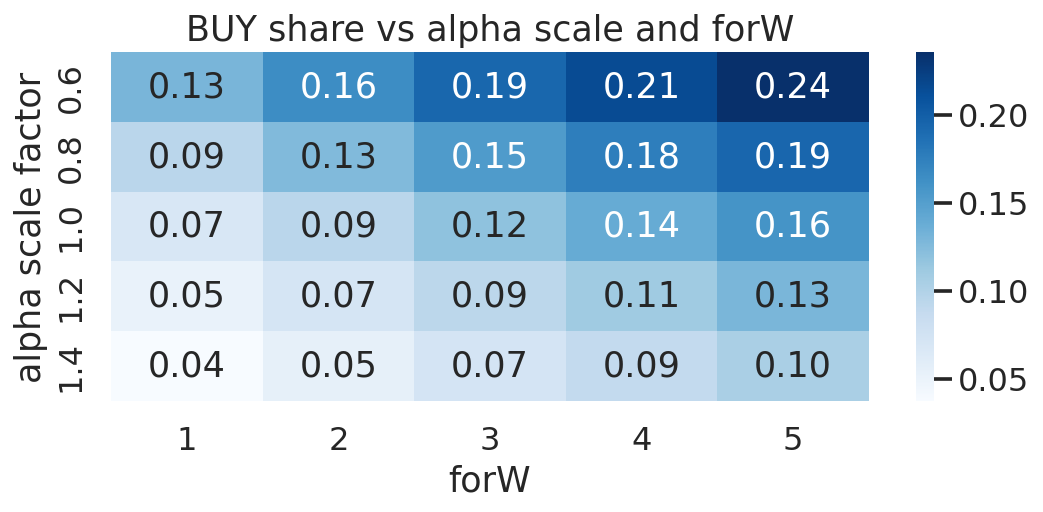

In [33]:
alpha_scale_summaries: List[pd.DataFrame] = []
for scale in ALPHA_SCALE_STUDY:
    alpha_candidate = alpha_base * scale
    beta_candidate = beta_base * scale
    scenario_name = f"alpha_scale={scale:0.2f}"
    df_summary = summarize_threshold_scenario(
        scenario=scenario_name,
        alpha_val=alpha_candidate,
        beta_base=beta_candidate,
        price_df=price_df,
        forward_lookup=forward_returns,
        backW_values=backW_values,
        forW_values=forW_values,
        scale_beta_per_step=scale_beta_per_step,
    )
    df_summary["alpha_scale"] = scale
    alpha_scale_summaries.append(df_summary)

if alpha_scale_summaries:
    alpha_scale_df = pd.concat(alpha_scale_summaries, ignore_index=True)
    alpha_scale_totals = aggregate_label_mix(alpha_scale_df)
    print("Alpha scaling sensitivity (scaling alpha & beta together):")
    display(alpha_scale_totals)
    heat = alpha_scale_df.pivot_table(
        index="alpha_scale",
        columns="forW",
        values="share_buy",
        aggfunc="mean",
    )
    fig = plt.figure(figsize=(8, 4))
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="Blues")
    plt.title("BUY share vs alpha scale and forW")
    plt.xlabel("forW")
    plt.ylabel("alpha scale factor")
    finalize_figure(fig, "alpha_scale_heatmap.png")
    plt.show()
else:
    print("Alpha scaling sensitivity skipped (no summaries).")

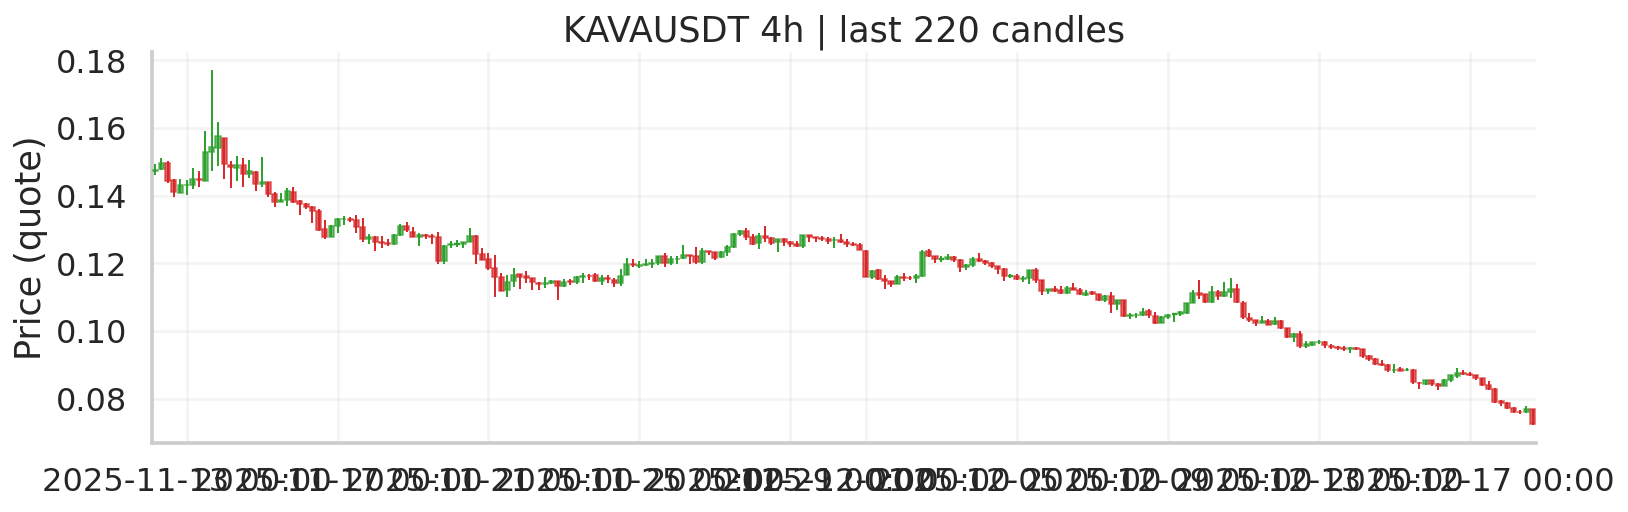

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_recent_candles(ax, price_df, lookback=RECENT_CANDLES, minutes_per_candle=interval_minutes,
                    title=f"{SYMBOL} {INTERVAL} | last {RECENT_CANDLES} candles")
finalize_figure(fig, "recent_candles.png")
plt.show()

In [35]:
window_examples


NameError: name 'window_examples' is not defined

In [ ]:
combo_pairs = [(b, f) for b in sorted(backW_values) for f in sorted(forW_values)]
if len(combo_pairs) >= 3:
    # sample_combos = [combo_pairs[0], combo_pairs[len(combo_pairs) // 2], combo_pairs[-1]]
    combo_pairs = list(filter(lambda x: x[1]<3 and x[0]>3, combo_pairs))
else:
    sample_combos = combo_pairs

window_examples = choose_window_examples(
    price_df=price_df,
    forward_lookup=forward_returns,
    combos=sample_combos,
    alpha_val=alpha_base,
    beta_base=beta_base,
    scale_beta_per_step=scale_beta_per_step,
    quantile=WINDOW_SAMPLE_QUANTILE,
)

if not window_examples:
    print("No valid window examples were found.")
else:
    fig, axes = plt.subplots(len(window_examples), 1, figsize=(12, 4.6 * len(window_examples)), sharex=False)
    if len(window_examples) == 1:
        axes = [axes]
    for ax, example in zip(axes, window_examples):
        plot_window_example(
            ax=ax,
            df=price_df,
            ts=example["ts"],
            backW=example["backW"],
            forW=example["forW"],
            forward_value=example["forward"],
            alpha_val=alpha_base,
            beta_val=example["beta"],
            minutes_per_candle=interval_minutes,
            pad_candles=WINDOW_CONTEXT_PAD,
        )
    axes[-1].set_xlabel("Time (UTC)")
    finalize_figure(fig, "window_examples.png")
    plt.show()


NameError: name 'sample_combos' is not defined

## Next steps
- Tweak `ALPHA_PERCENTILES_STUDY`, `BETA_PERCENTILES_STUDY`, or `ALPHA_SCALE_STUDY` and re-run to inspect Stage 2 mixes
- Swap `SYMBOL`/`INTERVAL` to inspect other Stage 2 pairs (uses processed/report files from Stage 2 paths)
- Feed the scenario summaries into downstream dataset selection or reporting as needed
